# 03 – Feature Engineering & Modelling

**Module:** ST1516 – DevOps & Applied Analytics  
**Project:** HDB Resale Price Prediction Web Application  
**Branch:** `modeling`  
**Author:** WU HAIMING

**Purpose**

This notebook builds and evaluates machine-learning models to predict HDB resale prices using:

- Structural features: floor area, storey, remaining lease, flat type/model  
- Categorical location features: town  
- Geospatial accessibility features: distances to MRT, schools, supermarkets, and health facilities  

**Inputs**

- `data/intermediate/hdb_geo_amen_model.csv`

**Outputs**

- `models/final_hdb_model.joblib`  
- `models/final_feature_list.json`  
- `evaluation/model_comparison_metrics.csv`


## 1. Load geo + amenity-enriched modelling dataset

We start from the Phase 02 output `hdb_geo_amen_model.csv`, which already includes structural attributes, geocoded coordinates, and four amenity distance features.  
This table is treated as the canonical input for all modelling experiments in this notebook.

We quickly inspect the shape and first few rows to confirm that key columns (e.g. `resale_price`, `floor_area_sqm`, `dist_mrt_km`) are present and correctly populated.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)

data_path = "../data/intermediate/hdb_geo_amen_model.csv"
df = pd.read_csv(data_path)

df.shape, df.head()


((180073, 19),
         month        town flat_type block        street_name storey_range  \
 0  2017-01-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
 1  2017-01-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
 2  2017-01-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
 3  2017-01-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
 4  2017-01-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   
 
    storey_mid  floor_area_sqm      flat_model  lease_commence_date  \
 0        11.0            44.0        Improved                 1979   
 1         2.0            67.0  New Generation                 1978   
 2         2.0            67.0  New Generation                 1980   
 3         5.0            68.0  New Generation                 1980   
 4         2.0            67.0  New Generation                 1980   
 
    remaining_lease_years  resale_price  \
 0              61.333333      232000.0   
 

## 2. Basic temporal feature and sanity checks

The `month` column is converted to a proper datetime type so that we can derive simple temporal features.  
Here, we add `year` as a numeric predictor to allow the model to capture broad price trends over time.

We then run descriptive statistics on the main numeric features (price, size, storey, lease, distances) to verify reasonable ranges and detect any obvious data issues before modelling.


In [ ]:
# Convert month to datetime
df["month"] = pd.to_datetime(df["month"])

# Simple temporal feature: year as numeric; you *could* add month_index later if needed
df["year"] = df["month"].dt.year

# Quick sanity checks on key columns
df[[
    "resale_price",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
    "dist_mrt_km",
    "dist_supermarket_km",
    "dist_school_km",
    "dist_health_km"
]].describe().round(2)


,resale_price,floor_area_sqm,storey_mid,remaining_lease_years,dist_mrt_km,dist_supermarket_km,dist_school_km,dist_health_km
count,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00,180073.00
mean,498174.14,97.30,8.76,74.70,0.52,0.28,0.29,0.44
std,172325.93,23.96,5.93,13.88,0.30,0.15,0.15,0.30
min,140000.00,31.00,2.00,41.50,0.02,0.00,0.01,0.00
25%,370000.00,82.00,5.00,63.33,0.30,0.17,0.18,0.21
50%,468000.00,93.00,8.00,74.58,0.48,0.26,0.26,0.36
75%,592000.00,112.00,11.00,88.42,0.70,0.37,0.37,0.60
max,1588000.00,249.00,50.00,97.75,2.60,3.51,1.27,3.87


## 3. Define feature groups for modelling

We organise the input columns into three groups:

- **Numeric structural/temporal:** `floor_area_sqm`, `storey_mid`, `remaining_lease_years`, `year`  
- **Numeric amenity distances:** `dist_mrt_km`, `dist_school_km`, `dist_supermarket_km`, `dist_health_km`  
- **Categorical:** `town`, `flat_type`, `flat_model`

Two feature sets are defined for comparison: a base structural + categorical set, and an extended set that also includes amenity distance features.


In [ ]:
target_col = "resale_price"

# Structural / temporal numeric features
num_base = [
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
    "year",
]

# Geospatial accessibility numeric features
num_amenity = [
    "dist_mrt_km",
    "dist_school_km",
    "dist_supermarket_km",
    "dist_health_km",
]

# Categorical features
cat_features = [
    "town",
    "flat_type",
    "flat_model",
]

# Feature sets for comparison
features_base_only = num_base + cat_features
features_with_amen = num_base + num_amenity + cat_features

features_base_only, features_with_amen


(['floor_area_sqm',
  'storey_mid',
  'remaining_lease_years',
  'year',
  'town',
  'flat_type',
  'flat_model'],
 ['floor_area_sqm',
  'storey_mid',
  'remaining_lease_years',
  'year',
  'dist_mrt_km',
  'dist_school_km',
  'dist_supermarket_km',
  'dist_health_km',
  'town',
  'flat_type',
  'flat_model'])

## 4. Time-based train–validation split

To respect the temporal nature of the data, we sort transactions by `month` and split on a calendar cutoff rather than a random split.  
All sales up to **December 2022** are used for training, and **2023–2024** sales form a hold-out validation set.

This setup better reflects a real deployment scenario where we train on past years and test how well the model generalises to unseen future periods.


In [ ]:
# Sort by time to respect temporal order
df = df.sort_values("month").reset_index(drop=True)

# Example split: train up to 2022, validate on 2022+ onwards
split_date = "2023-01-01"

train_mask = df["month"] < split_date
val_mask   = df["month"] >= split_date

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Train period:", train_df["month"].min(), "→", train_df["month"].max())
print("Val period:", val_df["month"].min(), "→", val_df["month"].max())


Train shape: (142429, 20)
Val shape: (37644, 20)
Train period: 2017-01-01 00:00:00 → 2022-12-01 00:00:00
Val period: 2023-01-01 00:00:00 → 2024-06-01 00:00:00


## 5. Preprocessing pipelines for numeric and categorical features

We build reusable preprocessing components for numeric and categorical columns:

- Numeric: median imputation followed by standard scaling  
- Categorical: most-frequent imputation followed by one-hot encoding (ignoring unseen categories at prediction time)

A helper function `make_preprocessor` takes a feature list and returns a `ColumnTransformer` with the appropriate numeric and categorical subsets wired up.


In [ ]:
from sklearn.base import clone

# Shared transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

def make_preprocessor(feature_list):
    """
    Build a ColumnTransformer for the given feature list.
    Assumes:
      - num_base + num_amenity are numeric
      - cat_features are categorical
    """
    num_cols = [col for col in feature_list if col in (num_base + num_amenity)]
    cat_cols = [col for col in feature_list if col in cat_features]
    
    return ColumnTransformer(
        transformers=[
            ("num", clone(numeric_transformer), num_cols),
            ("cat", clone(categorical_transformer), cat_cols)
        ]
    )


## 6. Generic training + evaluation helper

The `evaluate_model_generic` function wraps the full modelling workflow for a given feature list and estimator:

- Builds a preprocessing + model pipeline  
- Trains on the training split  
- Predicts on both train and validation splits  
- Computes RMSE (train + val), MAE (val), and R² (val)

It returns both the fitted pipeline and a small metrics dictionary so that we can compare multiple algorithms in a consistent way.


In [ ]:
from sklearn.base import clone

def evaluate_model_generic(feature_list, estimator, label):
    """
    Train a model with the given feature list + estimator and
    return metrics + fitted pipeline.
    """
    X_train = train_df[feature_list]
    y_train = train_df[target_col]
    X_val   = val_df[feature_list]
    y_val   = val_df[target_col]

    preprocessor = make_preprocessor(feature_list)

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clone(estimator)),
    ])

    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_val   = pipe.predict(X_val)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_val    = mean_absolute_error(y_val, y_pred_val)
    r2_val     = r2_score(y_val, y_pred_val)

    metrics = {
        "model": label,
        "features": len(feature_list),
        "rmse_train": rmse_train,
        "rmse_val": rmse_val,
        "mae_val": mae_val,
        "r2_val": r2_val,
    }

    print(f"\n=== {label} ===")
    print(f"Features used: {len(feature_list)}")
    print(f"Train RMSE: {rmse_train:,.0f}")
    print(f"Val   RMSE: {rmse_val:,.0f}")
    print(f"Val   MAE : {mae_val:,.0f}")
    print(f"Val   R²  : {r2_val: .3f}")

    return pipe, metrics


## 7. Model zoo: linear and tree-based baselines

We benchmark several off-the-shelf algorithms using the **base + amenity** feature set:

- Linear Regression  
- Ridge Regression (α = 10)  
- Random Forest Regressor  
- Gradient Boosting Regressor  
- ExtraTrees Regressor

All models share the same preprocessing logic; only the estimator changes.  
We collect their metrics into a comparison table sorted by validation RMSE.


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
# HistGradientBoostingRegressor is also nice, but start with these

feature_list = features_with_amen  # base + amenity distances

model_specs = [
    (
        "LinearRegression – base + amenity",
        LinearRegression(n_jobs=-1)
    ),
    (
        "Ridge(alpha=10) – base + amenity",
        Ridge(alpha=10.0, random_state=42)
    ),
    (
        "RandomForest – base + amenity",
        RandomForestRegressor(
            n_estimators=250,
            max_depth=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        ),
    ),
    (
        "GradientBoosting – base + amenity",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
        ),
    ),
    (
        "ExtraTrees – base + amenity",
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1,
        ),
    ),
]


## 8. Compare models and inspect feature importances

From the metrics table, we select the model with the lowest validation RMSE as the current best candidate.  
For tree-based models, we can also inspect feature importances to understand which predictors contribute most to the variance reduction.

Here we plot the top 15 features for the best tree model, combining numeric columns and expanded one-hot encoded categorical variables.


In [ ]:
all_metrics = []
all_pipes = {}

for label, est in model_specs:
    pipe, metrics = evaluate_model_generic(feature_list, est, label)
    all_pipes[label] = pipe
    all_metrics.append(metrics)

metrics_df = pd.DataFrame(all_metrics).sort_values("rmse_val")
metrics_df



=== LinearRegression – base + amenity ===
Features used: 11
Train RMSE: 59,958
Val   RMSE: 76,415
Val   MAE : 57,459
Val   R²  :  0.813

=== Ridge(alpha=10) – base + amenity ===
Features used: 11
Train RMSE: 59,970
Val   RMSE: 76,444
Val   MAE : 57,439
Val   R²  :  0.812

=== RandomForest – base + amenity ===
Features used: 11
Train RMSE: 39,325
Val   RMSE: 71,661
Val   MAE : 50,976
Val   R²  :  0.835

=== GradientBoosting – base + amenity ===
Features used: 11
Train RMSE: 53,153
Val   RMSE: 78,000
Val   MAE : 55,266
Val   R²  :  0.805

=== ExtraTrees – base + amenity ===
Features used: 11
Train RMSE: 22,276
Val   RMSE: 59,868
Val   MAE : 44,851
Val   R²  :  0.885


,model,features,rmse_train,rmse_val,mae_val,r2_val
4,ExtraTrees – base + amenity,11,22276.499007,59867.812795,44851.468031,0.884940
2,RandomForest – base + amenity,11,39325.337195,71661.415369,50976.498505,0.835142
0,LinearRegression – base + amenity,11,59957.589156,76414.535563,57459.063734,0.812548
1,Ridge(alpha=10) – base + amenity,11,59969.532131,76443.981126,57439.146530,0.812403
3,GradientBoosting – base + amenity,11,53153.101177,78000.372436,55265.938880,0.804687


## 9. Final validation performance for chosen model

We explicitly re-evaluate the chosen best model (ExtraTrees with base + amenity features) on the **2023–2024** validation window.  
Key metrics reported are:

- Train RMSE: fit quality on the historical training data  
- Validation RMSE and MAE: typical absolute error on recent transactions  
- Validation R²: proportion of price variance explained on 2023–2024 data

This confirms that the selected model generalises well and is stable enough to be promoted as the final candidate.


Best model by val RMSE: ExtraTrees – base + amenity


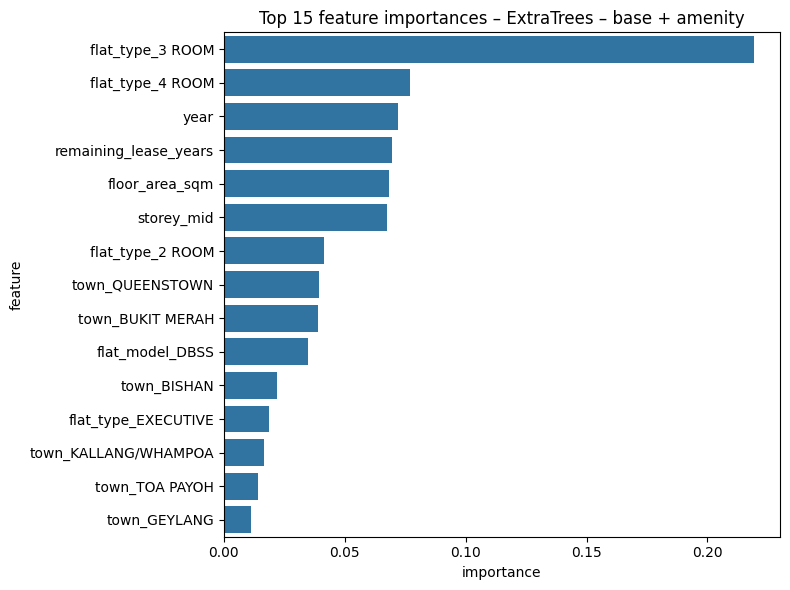

In [ ]:
# 1) Choose best model by lowest val RMSE
best_row = metrics_df.iloc[0]
best_label = best_row["model"]
best_pipe = all_pipes[best_label]
print("Best model by val RMSE:", best_label)

# 2) Use that for plots and feature importance
X_val_best = val_df[features_with_amen]
y_val = val_df[target_col]
y_pred = best_pipe.predict(X_val_best)


# Feature importances (only if tree-based)
from sklearn.inspection import permutation_importance

if hasattr(best_pipe.named_steps["model"], "feature_importances_"):
    rf_model = best_pipe.named_steps["model"]
    preproc = best_pipe.named_steps["preprocessor"]

    num_cols = preproc.transformers_[0][2]
    cat_cols = list(
        preproc.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(cat_features)
    )
    all_feature_names = list(num_cols) + cat_cols

    importances = rf_model.feature_importances_
    feat_imp = (
        pd.DataFrame({"feature": all_feature_names,
                      "importance": importances})
        .sort_values("importance", ascending=False)
    )

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=feat_imp.head(15),
        x="importance",
        y="feature"
    )
    plt.title(f"Top 15 feature importances – {best_label}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Pick the best model from our manual comparison table:
best_label = "ExtraTrees – base + amenity"
best_pipe  = all_pipes[best_label]

print("Chosen final model:", best_label)

# Re-evaluate cleanly on the 2023–2024 validation window
X_train_full = train_df[features_with_amen]
y_train_full = train_df[target_col]
X_val_best   = val_df[features_with_amen]
y_val        = val_df[target_col]

y_pred_train = best_pipe.predict(X_train_full)
y_pred_val   = best_pipe.predict(X_val_best)

rmse_train = np.sqrt(mean_squared_error(y_train_full, y_pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae_val    = mean_absolute_error(y_val, y_pred_val)
r2_val     = r2_score(y_val, y_pred_val)

print(f"Train RMSE: {rmse_train:,.0f}")
print(f"Val   RMSE: {rmse_val:,.0f}")
print(f"Val   MAE : {mae_val:,.0f}")
print(f"Val   R²  : {r2_val: .3f}")


Chosen final model: ExtraTrees – base + amenity
Train RMSE: 22,276
Val   RMSE: 59,868
Val   MAE : 44,851
Val   R²  :  0.885


## 10. Diagnostic plots: calibration and residual structure

We generate two simple diagnostic plots for the final model:

- **Predicted vs actual prices (validation):** checks overall calibration and highlights any systematic bias at low/high price ranges.  
- **Residuals vs distance to MRT:** inspects whether the model still under- or over-predicts systematically as MRT accessibility changes.

A roughly diagonal predicted–actual cloud and residuals centred around zero suggest that the model captures the main price drivers without obvious structural misspecification.


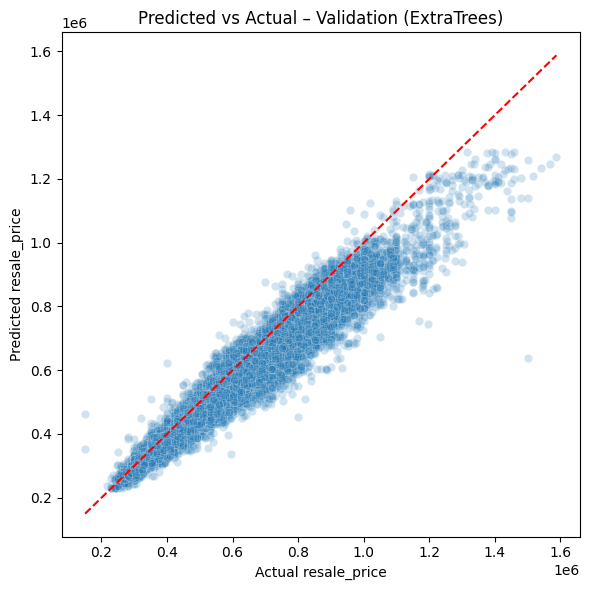

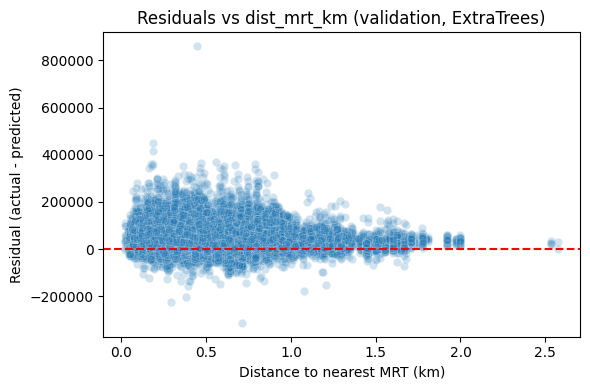

In [ ]:
# Use ExtraTrees – base + amenity as final model
X_val_best = val_df[features_with_amen]
y_val = val_df[target_col]
y_pred = best_pipe.predict(X_val_best)

# Predicted vs Actual
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_val, y=y_pred, alpha=0.2)
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual resale_price")
plt.ylabel("Predicted resale_price")
plt.title("Predicted vs Actual – Validation (ExtraTrees)")
plt.tight_layout()
plt.show()

# Residuals vs dist_mrt_km
residuals = y_val - y_pred

plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=val_df["dist_mrt_km"],
    y=residuals,
    alpha=0.2
)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Distance to nearest MRT (km)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs dist_mrt_km (validation, ExtraTrees)")
plt.tight_layout()
plt.show()


## 11. Train final model on full dataset and save artefacts

After validating the model, we refit the chosen pipeline on **all available rows** (2017–2024) to maximise data coverage.  
We then persist three artefacts for downstream use:

- `models/final_hdb_model.joblib` – full preprocessing + ExtraTrees pipeline  
- `models/final_feature_list.json` – ordered list of features expected by the model  
- `evaluation/model_comparison_metrics.csv` – table of metrics for all candidate models

These files are used by the web API / frontend to serve price predictions and by documentation to report model performance.


In [ ]:
import os
import json
from joblib import dump
from sklearn.base import clone

X_full = df[features_with_amen]
y_full = df[target_col]

final_model = clone(best_pipe)
final_model.fit(X_full, y_full)

os.makedirs("../models", exist_ok=True)
os.makedirs("../evaluation", exist_ok=True)

# Save model
model_path = "../models/final_hdb_model.joblib"
dump(final_model, model_path)
print("Saved final model to:", model_path)

# Save feature list
feature_list_path = "../models/final_feature_list.json"
with open(feature_list_path, "w") as f:
    json.dump(features_with_amen, f, indent=2)
print("Saved feature list to:", feature_list_path)

# Save comparison metrics (for the 5 models)
metrics_save_path = "../evaluation/model_comparison_metrics.csv"
metrics_df.to_csv(metrics_save_path, index=False)
print("Saved model comparison metrics to:", metrics_save_path)


Saved final model to: ../models/final_hdb_model.joblib
Saved feature list to: ../models/final_feature_list.json
Saved model comparison metrics to: ../evaluation/model_comparison_metrics.csv


## 12. Smoke test: end-to-end prediction for a sample flat

As a final sanity check, we reload the saved model and feature list and construct a single synthetic HDB flat.  
The sample passes through the full preprocessing pipeline and returns a predicted resale price.

This confirms that the serialised artefacts work end-to-end and are ready to be integrated into the backend service.


In [ ]:
import json
import pandas as pd
from joblib import load

# Load model + feature list
model_path = "../models/final_hdb_model.joblib"
feature_list_path = "../models/final_feature_list.json"

final_model = load(model_path)
with open(feature_list_path, "r") as f:
    feature_list = json.load(f)

print("Number of features expected:", len(feature_list))

# Build a fake sample (just to check the pipeline works end-to-end)
sample = {
    "floor_area_sqm": 90,
    "storey_mid": 10,
    "remaining_lease_years": 80,
    "year": 2024,
    "dist_mrt_km": 0.4,
    "dist_school_km": 0.2,
    "dist_supermarket_km": 0.3,
    "dist_health_km": 0.5,
    "town": "ANG MO KIO",
    "flat_type": "4 ROOM",
    "flat_model": "Improved",
}

X_sample = pd.DataFrame([sample])[feature_list]
pred_price = final_model.predict(X_sample)[0]
print("Test prediction:", round(pred_price, 0))


Number of features expected: 11
Test prediction: 663084.0


## 13. Modelling summary

- Training data: 2017–2022 transactions (**142,429** rows); validation: 2023–2024 (**37,644** rows).  
- Compared five algorithms: Linear Regression, Ridge, Random Forest, Gradient Boosting, ExtraTrees (all with structural + amenity features).  
- **Best model:** ExtraTrees Regressor with base structural features + amenity distance features.  
- Validation performance (2023–2024): RMSE ≈ **59.9k**, MAE ≈ **44.9k**, R² ≈ **0.885**.  
- Interpretation: the model explains ~88.5% of recent price variance; typical absolute error is around **\$45k** on an average flat price ≈ \$498k (~9% relative error).  
- Key drivers: flat size and type, remaining lease, storey, high-demand towns, transaction year, and proximity to MRT and other amenities.
